# Comparación de Curvas ROC - Modelos Base
## Spotify Churn Prediction

Este notebook compara las curvas ROC de los 5 modelos base sin reducción de dimensionalidad.

## 1. Importar librerías

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import os
# Métricas
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, classification_report


import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"
print("✓ Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## 2. Cargar datos

In [ ]:
filepath = os.path.expanduser('~/Documents/spotify_churn_dataset.csv')
df = pd.read_csv(filepath)

print(f"Dataset cargado: {df.shape[0]} usuarios, {df.shape[1]} variables")
print(f"\nDistribución de clases:\n{df['is_churned'].value_counts()}")
print(f"\nPorcentaje Churn: {df['is_churned'].sum() / len(df) * 100:.2f}%")

Dataset cargado: 8000 usuarios, 12 variables

Distribución de clases:
is_churned
0    5929
1    2071
Name: count, dtype: int64

Porcentaje Churn: 25.89%


## 3. Preprocesar datos (igual que en los notebooks)

In [15]:
# Separar features y target
X = df.drop(['user_id', 'is_churned', 'offline_listening'], axis=1)
y = df['is_churned']

# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Features numéricas: {len(numeric_features)}")
print(f"Features categóricas: {len(categorical_features)}")
print(f"Total features: {X.shape[1]}")

# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Train-test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicar preprocesamiento
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"\nX_train transformado: {X_train_transformed.shape}")
print(f"X_test transformado: {X_test_transformed.shape}")

Features numéricas: 5
Features categóricas: 4
Total features: 9

X_train transformado: (6400, 19)
X_test transformado: (1600, 19)


## 4. Entrenar 5 modelos y obtener curvas ROC

In [16]:
# Diccionario para almacenar resultados
roc_results = {}

print("Entrenando modelos...\n")
print("="*70)

Entrenando modelos...



### 4.1 Regresión Logística

In [17]:
print("\n1. REGRESIÓN LOGÍSTICA")
print("-" * 70)

pipeline_rl = ImbPipeline([
    ('poly', PolynomialFeatures(degree=1, include_bias=False)),
    ('smote', SMOTE(random_state=42)),
    ('logistic', LogisticRegression(max_iter=3000, random_state=42, solver='saga'))
])

param_grid_rl = {
    'logistic__C': [0.01, 0.1, 1, 10],
    'logistic__penalty': ['l1', 'l2']
}

grid_search_rl = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=param_grid_rl,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_rl.fit(X_train_transformed, y_train)
best_model_rl = grid_search_rl.best_estimator_

y_probs_rl = best_model_rl.predict_proba(X_test_transformed)[:, 1]
fpr_rl, tpr_rl, _ = roc_curve(y_test, y_probs_rl)
roc_auc_rl = auc(fpr_rl, tpr_rl)

roc_results['Regresión Logística'] = {
    'fpr': fpr_rl,
    'tpr': tpr_rl,
    'auc': roc_auc_rl,
    'color': '#1F77B4'
}

print(f"✓ AUC-ROC: {roc_auc_rl:.4f}")
print(f"Parámetros: {grid_search_rl.best_params_}")


1. REGRESIÓN LOGÍSTICA
----------------------------------------------------------------------
✓ AUC-ROC: 0.4983
Parámetros: {'logistic__C': 0.01, 'logistic__penalty': 'l2'}


### 4.2 KNN (K-Nearest Neighbors)

In [18]:
print("\n2. K-NEAREST NEIGHBORS (KNN)")
print("-" * 70)

pipeline_knn = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 7, 15, 25],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_knn.fit(X_train_transformed, y_train)
best_model_knn = grid_search_knn.best_estimator_

y_probs_knn = best_model_knn.predict_proba(X_test_transformed)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_probs_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

roc_results['KNN'] = {
    'fpr': fpr_knn,
    'tpr': tpr_knn,
    'auc': roc_auc_knn,
    'color': '#FF7F0E'
}

print(f"✓ AUC-ROC: {roc_auc_knn:.4f}")
print(f"Parámetros: {grid_search_knn.best_params_}")


2. K-NEAREST NEIGHBORS (KNN)
----------------------------------------------------------------------
✓ AUC-ROC: 0.5409
Parámetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}


### 4.3 Random Forest

In [19]:
print("\n3. RANDOM FOREST")
print("-" * 70)

pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [10, 20],
    'rf__min_samples_split': [2, 5]
}

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_rf.fit(X_train_transformed, y_train)
best_model_rf = grid_search_rf.best_estimator_

y_probs_rf = best_model_rf.predict_proba(X_test_transformed)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

roc_results['Random Forest'] = {
    'fpr': fpr_rf,
    'tpr': tpr_rf,
    'auc': roc_auc_rf,
    'color': '#2CA02C'
}

print(f"✓ AUC-ROC: {roc_auc_rf:.4f}")
print(f"Parámetros: {grid_search_rf.best_params_}")


3. RANDOM FOREST
----------------------------------------------------------------------
✓ AUC-ROC: 0.5379
Parámetros: {'rf__max_depth': 20, 'rf__min_samples_split': 5, 'rf__n_estimators': 50}


### 4.4 SVM (Support Vector Machine)

In [20]:
print("\n4. SUPPORT VECTOR MACHINE (SVM)")
print("-" * 70)

pipeline_svm = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

grid_search_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_svm.fit(X_train_transformed, y_train)
best_model_svm = grid_search_svm.best_estimator_

y_probs_svm = best_model_svm.predict_proba(X_test_transformed)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_probs_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

roc_results['SVM'] = {
    'fpr': fpr_svm,
    'tpr': tpr_svm,
    'auc': roc_auc_svm,
    'color': '#D62728'
}

print(f"✓ AUC-ROC: {roc_auc_svm:.4f}")
print(f"Parámetros: {grid_search_svm.best_params_}")


4. SUPPORT VECTOR MACHINE (SVM)
----------------------------------------------------------------------
✓ AUC-ROC: 0.5047
Parámetros: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


### 4.5 Red Neuronal Artificial (MLP)

In [21]:
print("\n5. RED NEURONAL ARTIFICIAL (MLP)")
print("-" * 70)

pipeline_nn = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('nn', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

param_grid_nn = {
    'nn__hidden_layer_sizes': [(100,), (50, 25)],
    'nn__activation': ['relu', 'tanh'],
    'nn__alpha': [0.001, 0.01]
}

grid_search_nn = GridSearchCV(
    estimator=pipeline_nn,
    param_grid=param_grid_nn,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_nn.fit(X_train_transformed, y_train)
best_model_nn = grid_search_nn.best_estimator_

y_probs_nn = best_model_nn.predict_proba(X_test_transformed)[:, 1]
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_probs_nn)
roc_auc_nn = auc(fpr_nn, tpr_nn)

roc_results['Red Neuronal'] = {
    'fpr': fpr_nn,
    'tpr': tpr_nn,
    'auc': roc_auc_nn,
    'color': '#9467BD'
}

print(f"✓ AUC-ROC: {roc_auc_nn:.4f}")
print(f"Parámetros: {grid_search_nn.best_params_}")

print("\n" + "="*70)
print("✓ Todos los modelos entrenados exitosamente")


5. RED NEURONAL ARTIFICIAL (MLP)
----------------------------------------------------------------------
✓ AUC-ROC: 0.5287
Parámetros: {'nn__activation': 'tanh', 'nn__alpha': 0.01, 'nn__hidden_layer_sizes': (100,)}

✓ Todos los modelos entrenados exitosamente


## 5. Visualizar comparación de curvas ROC

✓ Gráfica guardada como 'ROC_Comparacion_Modelos_Base.png'


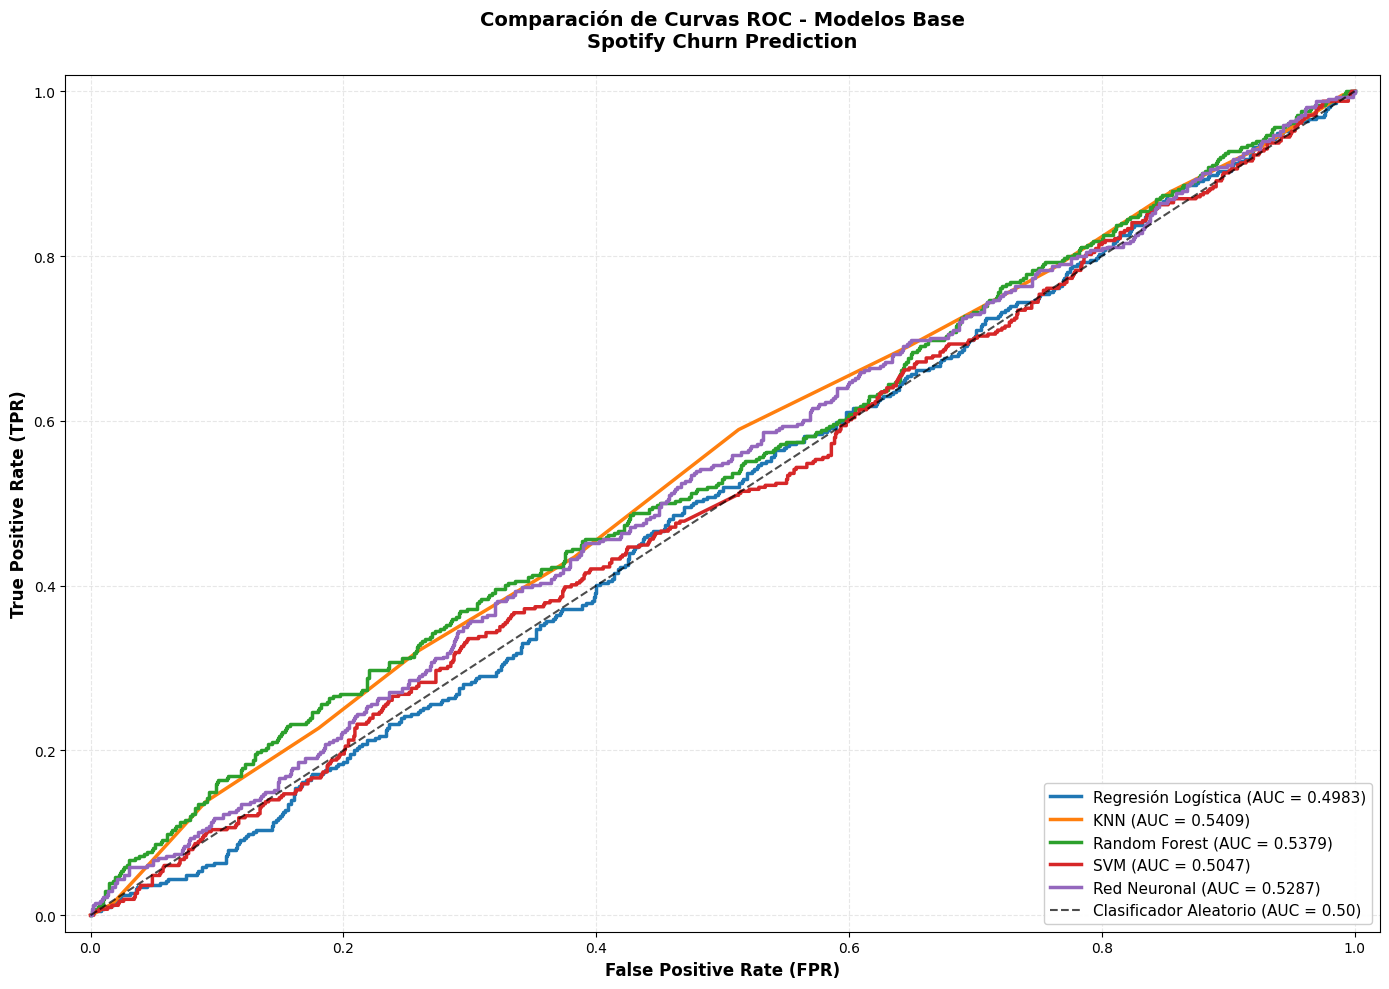

In [22]:
# Crear figura con tamaño grande
plt.figure(figsize=(14, 10))

# Plotear cada curva ROC
for model_name, results in roc_results.items():
    plt.plot(
        results['fpr'],
        results['tpr'],
        color=results['color'],
        lw=2.5,
        label=f"{model_name} (AUC = {results['auc']:.4f})"
    )

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador Aleatorio (AUC = 0.50)', alpha=0.7)

# Configuración de la gráfica
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
plt.title('Comparación de Curvas ROC - Modelos Base\nSpotify Churn Prediction', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Guardar figura
plt.savefig('ROC_Comparacion_Modelos_Base.png', dpi=300, bbox_inches='tight')
print("✓ Gráfica guardada como 'ROC_Comparacion_Modelos_Base.png'")

plt.show()

## 6. Tabla resumen de resultados

In [23]:
# Crear tabla de resultados
results_summary = []

for model_name, results in roc_results.items():
    results_summary.append({
        'Modelo': model_name,
        'AUC-ROC': f"{results['auc']:.4f}"
    })

df_results = pd.DataFrame(results_summary)
df_results = df_results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("RESUMEN DE RESULTADOS - MODELOS BASE")
print("="*50)
print(df_results.to_string(index=False))
print("="*50)

# Identificar mejor modelo
best_model_name = df_results.iloc[0]['Modelo']
best_auc = df_results.iloc[0]['AUC-ROC']
print(f"\n🏆 Mejor modelo: {best_model_name} con AUC-ROC = {best_auc}")


RESUMEN DE RESULTADOS - MODELOS BASE
             Modelo AUC-ROC
                KNN  0.5409
      Random Forest  0.5379
       Red Neuronal  0.5287
                SVM  0.5047
Regresión Logística  0.4983

🏆 Mejor modelo: KNN con AUC-ROC = 0.5409


## 7. Análisis detallado por modelo

In [24]:
print("\n" + "="*70)
print("ANÁLISIS DETALLADO POR MODELO")
print("="*70)

# Regresión Logística
y_pred_rl = best_model_rl.predict(X_test_transformed)
print("\n1. REGRESIÓN LOGÍSTICA")
print(f"   AUC-ROC: {roc_auc_rl:.4f}")
print(f"   Accuracy: {(y_pred_rl == y_test).mean():.4f}")

# KNN
y_pred_knn = best_model_knn.predict(X_test_transformed)
print("\n2. K-NEAREST NEIGHBORS")
print(f"   AUC-ROC: {roc_auc_knn:.4f}")
print(f"   Accuracy: {(y_pred_knn == y_test).mean():.4f}")

# Random Forest
y_pred_rf = best_model_rf.predict(X_test_transformed)
print("\n3. RANDOM FOREST")
print(f"   AUC-ROC: {roc_auc_rf:.4f}")
print(f"   Accuracy: {(y_pred_rf == y_test).mean():.4f}")

# SVM
y_pred_svm = best_model_svm.predict(X_test_transformed)
print("\n4. SUPPORT VECTOR MACHINE")
print(f"   AUC-ROC: {roc_auc_svm:.4f}")
print(f"   Accuracy: {(y_pred_svm == y_test).mean():.4f}")

# Red Neuronal
y_pred_nn = best_model_nn.predict(X_test_transformed)
print("\n5. RED NEURONAL ARTIFICIAL")
print(f"   AUC-ROC: {roc_auc_nn:.4f}")
print(f"   Accuracy: {(y_pred_nn == y_test).mean():.4f}")

print("\n" + "="*70)


ANÁLISIS DETALLADO POR MODELO

1. REGRESIÓN LOGÍSTICA
   AUC-ROC: 0.4983
   Accuracy: 0.5156

2. K-NEAREST NEIGHBORS
   AUC-ROC: 0.5409
   Accuracy: 0.5700

3. RANDOM FOREST
   AUC-ROC: 0.5379
   Accuracy: 0.7144

4. SUPPORT VECTOR MACHINE
   AUC-ROC: 0.5047
   Accuracy: 0.5025

5. RED NEURONAL ARTIFICIAL
   AUC-ROC: 0.5287
   Accuracy: 0.4888

